# Point Cloud Transformers Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import open3d as o3d
import trimesh
import matplotlib.pyplot as plt
import os

from mpl_toolkits.mplot3d import Axes3D  # noqa
from pathlib import Path
from visuals import visualize_samples

%load_ext autoreload
%autoreload 2

## Comparative Visual for Report

Just a quick visual to show the different datasets.

In [2]:
# Load all PAPNet and PCT data
pap_partial = np.load(os.path.join('..', 'datasets', 'partialmodelnet40', 'train_points.npy'))
pap_full = np.load(os.path.join('..', 'datasets', 'fullmodelnet40', 'train_points.npy'))
pap_partial_10 = np.load(os.path.join('..', 'datasets', 'pm40_partiality_level', 'train_points_10.npy'))
pap_partial_30 = np.load(os.path.join('..', 'datasets', 'pm40_partiality_level', 'train_points_30.npy'))
pap_partial_40 = np.load(os.path.join('..', 'datasets', 'pm40_partiality_level', 'train_points_40.npy'))

# Loads PCT style data, only the airplane folder
folder = Path(os.path.join('..', 'datasets', 'modelnet40_normal_resampled', 'airplane'))
files = sorted(folder.glob('*.txt'))
arrays = []
for f in files:
    arr = np.loadtxt(f, delimiter=',')
    arrays.append(arr)
pct_airplanes = np.stack(arrays, axis=0)

In [3]:
# Gather samples for combined plot
viz_points = [
    pap_partial[4],
    pap_full[4],
    pct_airplanes[0],
    pap_partial_10[4],
    pap_partial_30[4],
    pap_partial_40[4]
]

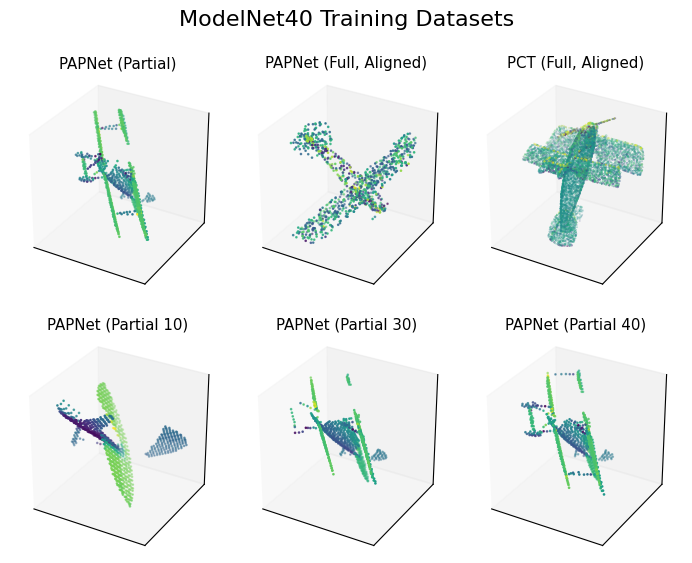

In [4]:
visualize_samples(
    data=viz_points,
    title='ModelNet40 Training Datasets',
    figsize=(7, 6),
    labels=[
        'PAPNet (Partial)', 'PAPNet (Full, Aligned)', 'PCT (Full, Aligned)',
        'PAPNet (Partial 10)', 'PAPNet (Partial 30)', 'PAPNet (Partial 40)'
    ],
    point_size=[0.8, 0.8, 0.05, 0.8, 0.8, 0.8],
    font_size=9
)

In [ ]:
# Too much for my RAM, delete, otherwise my notebook kernel gets stuck on something...
del pap_partial_10
del pap_partial_30
del pap_partial_40

## Performance Analytics

In [6]:
pct_results = pd.read_csv('../runs/pct_results.csv', sep=';')
pct_results.head(5)

,y_true,pct_pct,pct_pap,pap_pap,pap_pct
0,0,0,19,0,0
1,0,0,9,0,0
2,0,0,9,0,33
3,0,0,27,0,0
4,0,0,17,0,0


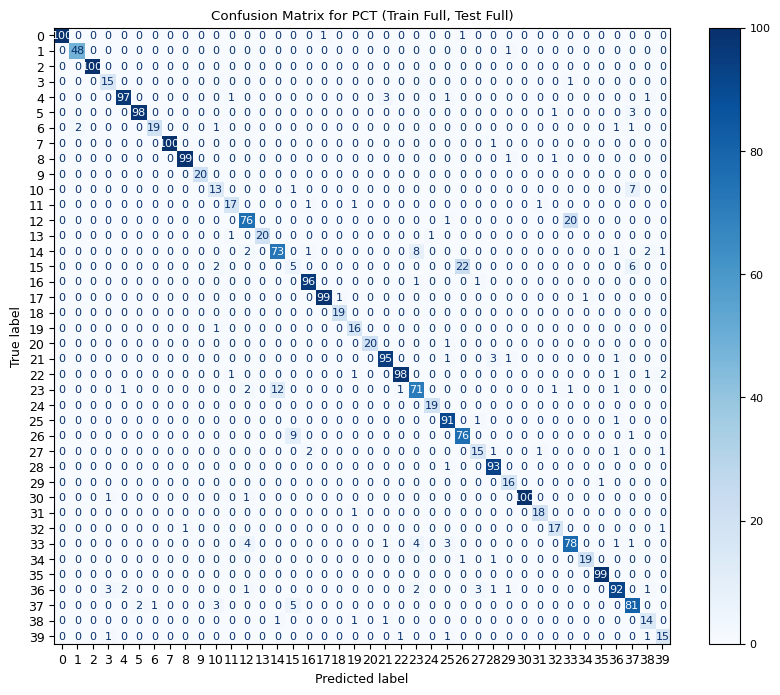

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.rcParams.update({'font.size': 8})

cm = confusion_matrix(pct_results.pct_pct, pct_results.y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for PCT (Train Full, Test Full)")
plt.show()

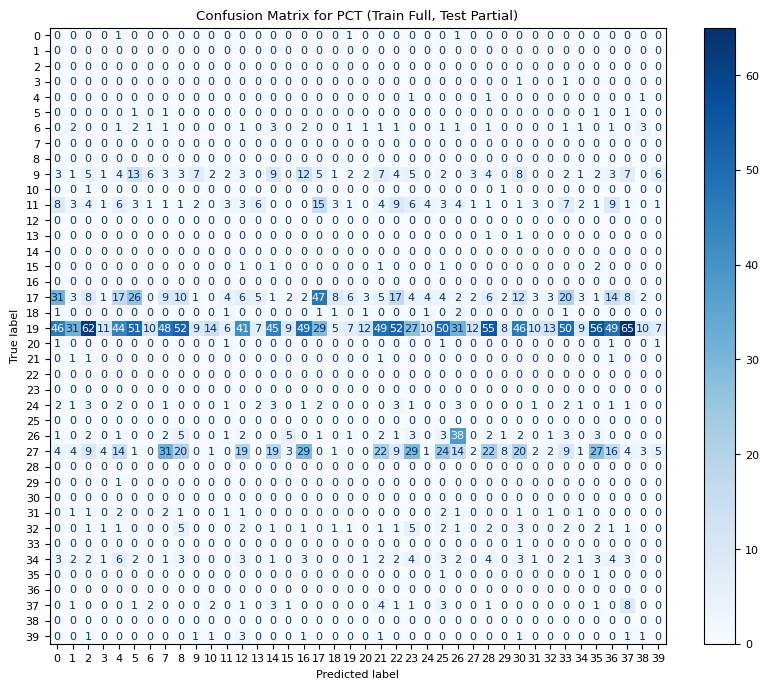

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.rcParams.update({'font.size': 8})

cm = confusion_matrix(pct_results.pct_pap, pct_results.y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for PCT (Train Full, Test Partial)")
plt.show()

In [21]:
# Let's look at category 17, 19, and 27 to see what they have in common to cause the model to collapse
test_names = [line.rstrip() for line in open(os.path.join('..', 'datasets', 'modelnet40_normal_resampled', 'modelnet40_test.txt'))]
pap_test = np.load(os.path.join('..', 'datasets', 'partialmodelnet40', 'test_points.npy'))

test_df = pd.DataFrame(test_names, columns=['Category'])
test_df[['Category', 'Instance']] = test_df['Category'].str.rsplit('_', n=1, expand=True)
test_df['y_true'] = pct_results['y_true']

test_df[test_df['y_true'].isin([17, 19, 27])]

,Category,Instance,y_true
1062,guitar,0156,17
1063,guitar,0157,17
1064,guitar,0158,17
1065,guitar,0159,17
1066,guitar,0160,17
...,...,...,...
1743,radio,0120,27
1744,radio,0121,27
1745,radio,0122,27
1746,radio,0123,27


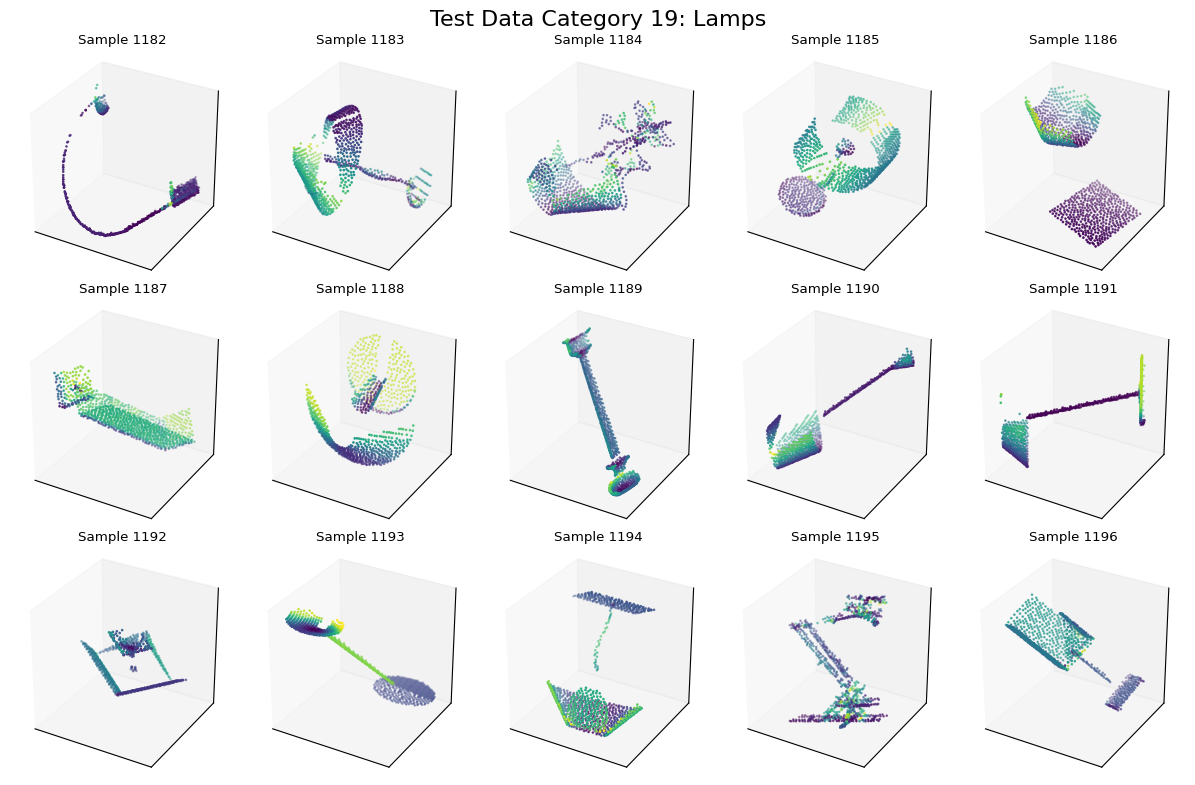

In [26]:
visualize_samples(
    data=pap_test,
    indices=range(1182, 1182 + 15),
    title='Test Data Category 19: Lamps',
    plot_dims=(3, 5)
)

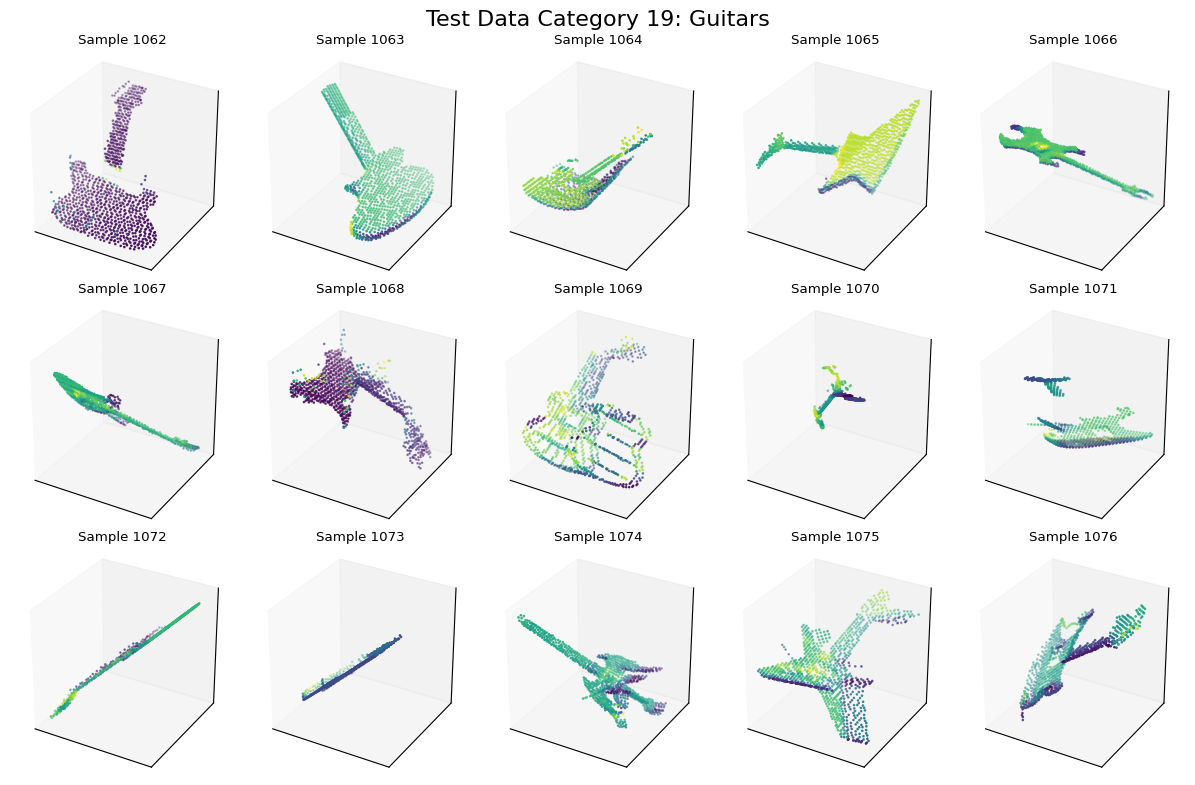

In [27]:
visualize_samples(
    data=pap_test,
    indices=range(1062, 1062 + 15),
    title='Test Data Category 19: Guitars',
    plot_dims=(3, 5)
)

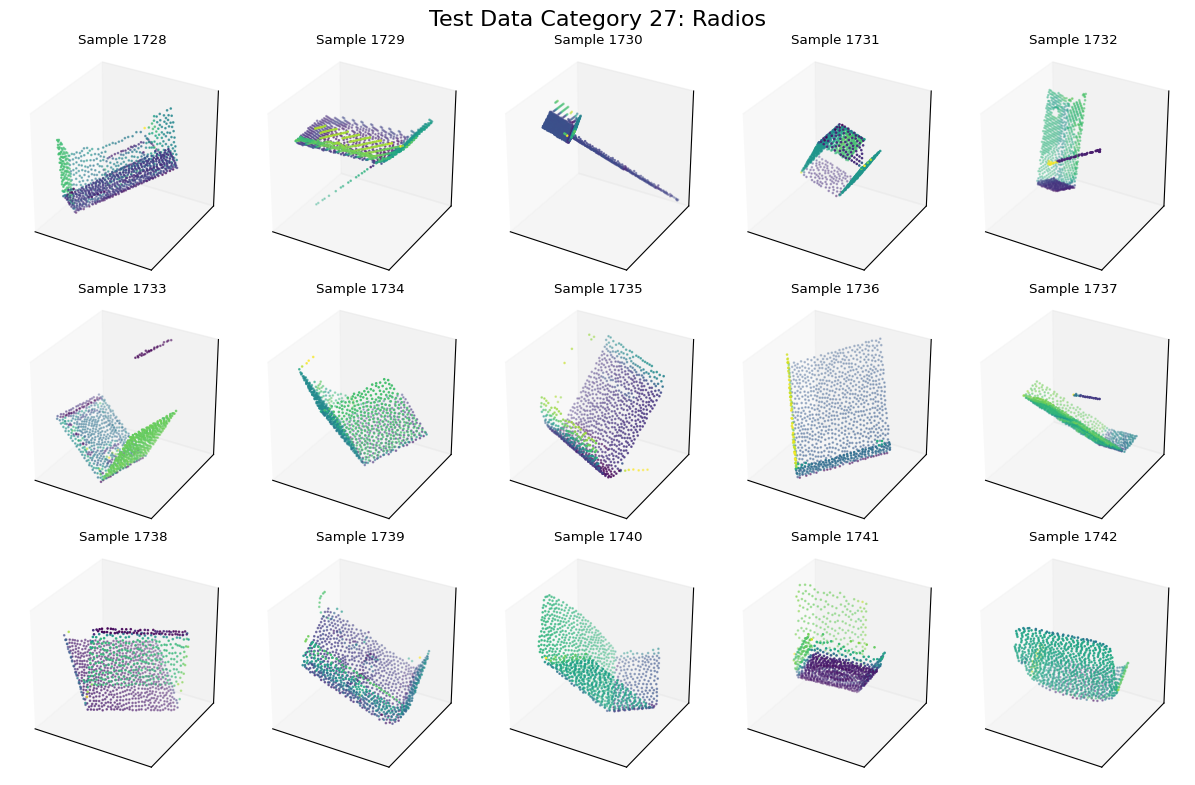

In [28]:
visualize_samples(
    data=pap_test,
    indices=range(1728, 1728 + 15),
    title='Test Data Category 27: Radios',
    plot_dims=(3, 5)
)

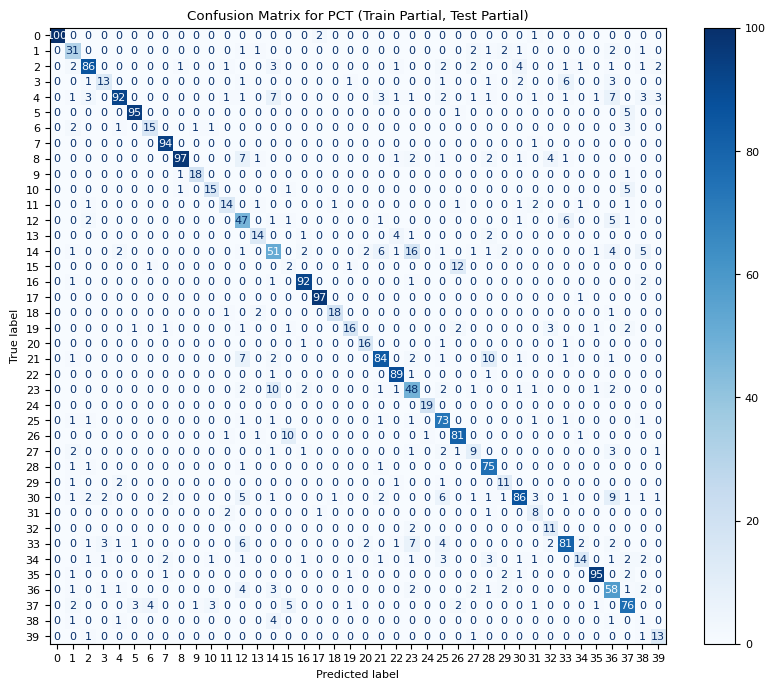

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.rcParams.update({'font.size': 8})

cm = confusion_matrix(pct_results.pap_pap, pct_results.y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for PCT (Train Partial, Test Partial)")
plt.show()

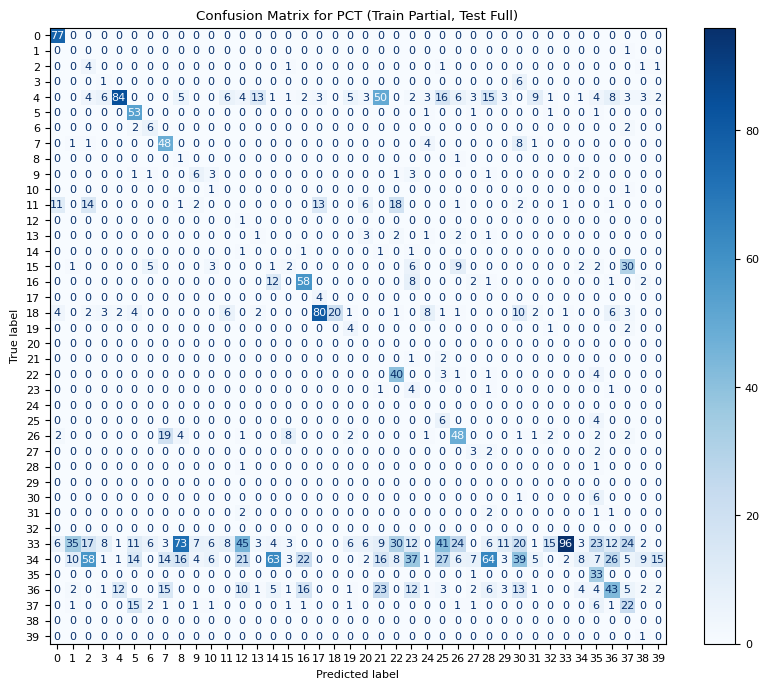

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.rcParams.update({'font.size': 8})

cm = confusion_matrix(pct_results.pap_pct, pct_results.y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for PCT (Train Partial, Test Full)")
plt.show()

In [32]:
test_df[test_df['y_true'].isin([33, 34])]

,Category,Instance,y_true
2008,table,0393,33
2009,table,0394,33
2010,table,0395,33
2011,table,0396,33
2012,table,0397,33
...,...,...,...
2123,tent,0179,34
2124,tent,0180,34
2125,tent,0181,34
2126,tent,0182,34


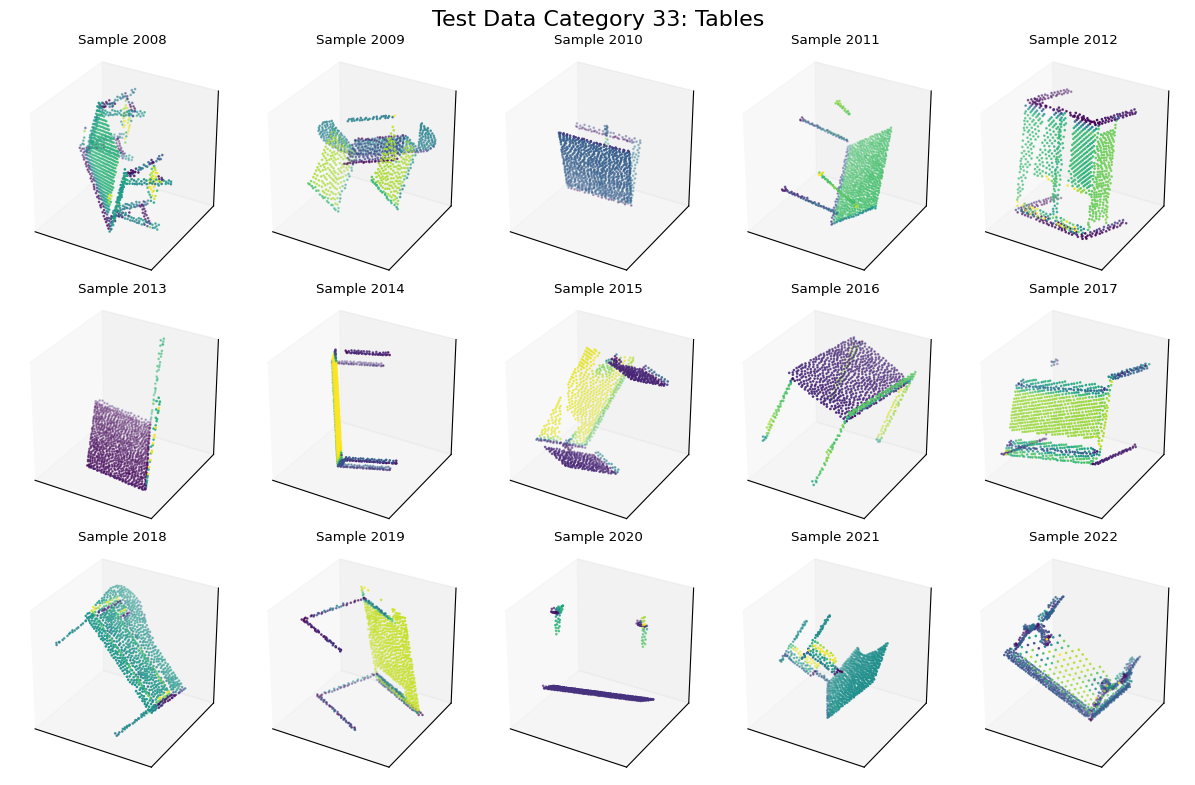

In [33]:
visualize_samples(
    data=pap_test,
    indices=range(2008, 2008 + 15),
    title='Test Data Category 33: Tables',
    plot_dims=(3, 5)
)

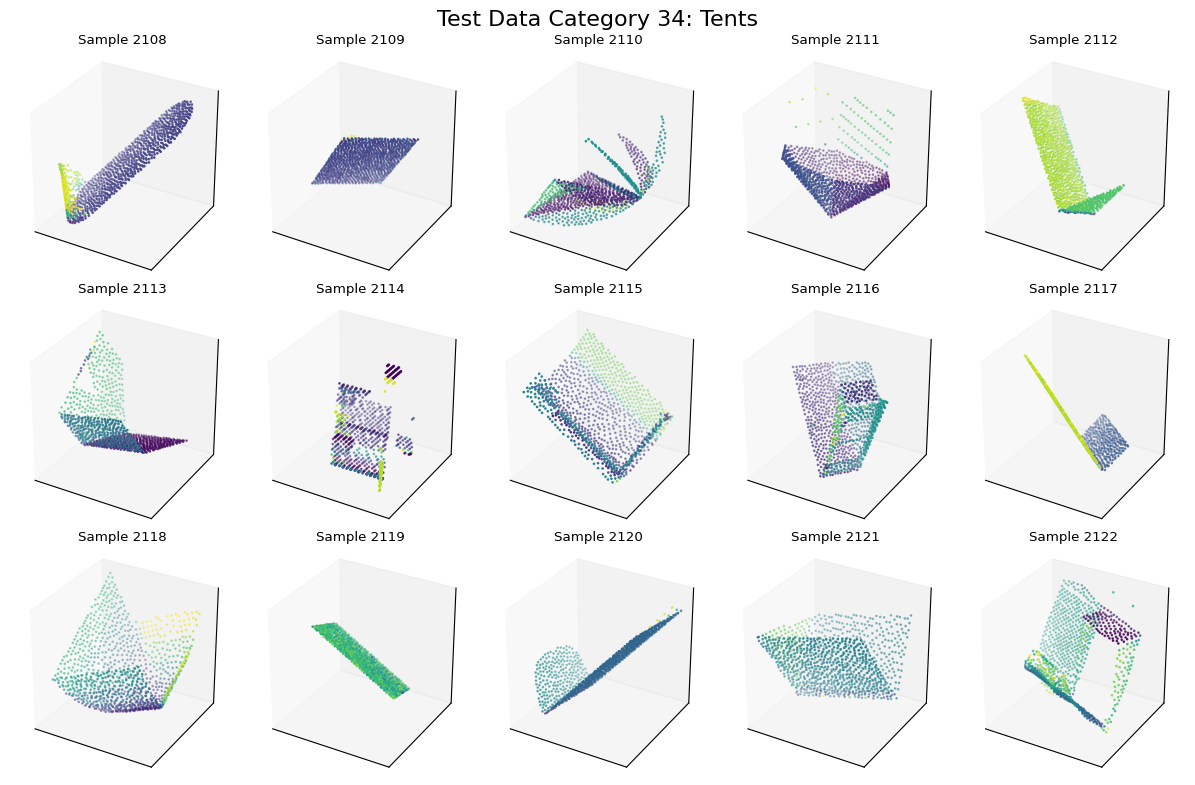

In [35]:
visualize_samples(
    data=pap_test,
    indices=range(2108, 2108 + 15),
    title='Test Data Category 34: Tents',
    plot_dims=(3, 5)
)